<a href="https://colab.research.google.com/github/rs3192398-del/Data-science-session/blob/main/logistic_regression_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [ ]:
np.random.seed(42)
n = 300

data = pd.DataFrame({
  "age": np.random.randint(18, 60, n),
  "salary": np.random.randint(20000, 100000, n),
  "balance": np.random.randint(0, 200000, n)
  })
#create binary target
data["churn"] = (
    (data["balance"] > 100000).astype(int) |
    (data["salary"] < 40000).astype(int)
).astype(int)
data.head()

,age,salary,balance,churn
0,56,59790,52528,0
1,46,25600,38413,1
2,32,60764,52638,0
3,25,94543,183808,1
4,38,65714,110133,1


In [ ]:
print(data.shape)
print(data.info())
print(data.describe())
print(data['churn'].value_counts())

(300, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   age      300 non-null    int64
 1   salary   300 non-null    int64
 2   balance  300 non-null    int64
 3   churn    300 non-null    int64
dtypes: int64(4)
memory usage: 9.5 KB
None
              age        salary        balance       churn
count  300.000000    300.000000     300.000000  300.000000
mean    38.990000  59709.816667   96847.946667    0.646667
std     12.408187  22810.772819   55771.345393    0.478804
min     18.000000  20301.000000     404.000000    0.000000
25%     28.000000  40126.500000   50301.500000    0.000000
50%     40.000000  59189.500000  102245.500000    1.000000
75%     50.000000  79116.500000  141552.500000    1.000000
max     59.000000  99634.000000  199938.000000    1.000000
churn
1    194
0    106
Name: count, dtype: int64


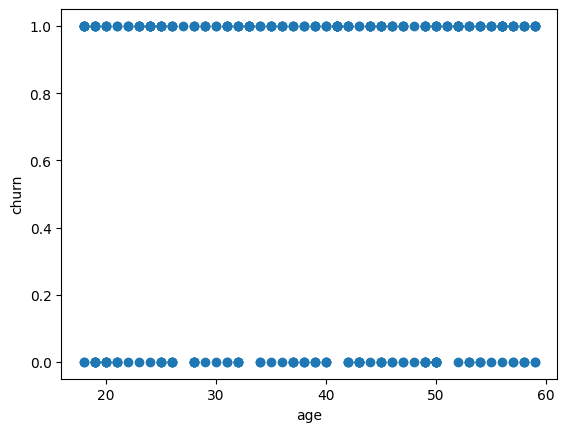

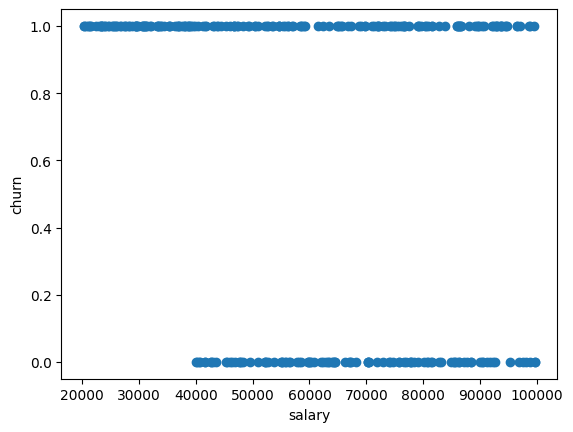

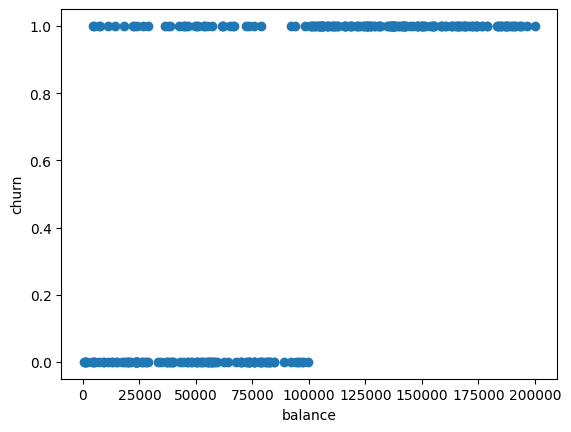

In [ ]:
features = ["age", "salary", "balance"]

for col in features:
  plt.figure()
  plt.scatter(data[col], data["churn"])
  plt.xlabel(col)
  plt.ylabel("churn")
  plt.show()

In [ ]:
x=data[["age", "salary", "balance"]]
y=data["churn"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
    )


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
print(y_pred)

[1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1
 0 1 1 0 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0]


In [ ]:
x_pred = model.predict(x_test)
print(x_test)

     age  salary  balance
203   51   61555   149849
266   42   46790   109779
152   47   79275   187872
9     28   63484   155576
233   40   31174    44247
226   56   31130   131127
196   49   40150    36668
109   57   29662    92193
5     56   76835   106357
175   41   31338   155286
237   52   94460   146106
57    21   96429   168964
218   20   79163   183868
45    45   25801   122402
182   34   38888   108215
221   49   52307    64291
289   47   56395    76090
211   33   36779    22574
148   23   69115   192958
165   25   45351    73477
78    46   86412   131456
113   18   87215    14489
249   52   59081   105186
250   36   82856    34674
104   50   76556    57091
42    43   47751    82844
281   25   72224   100776
295   51   41732   116148
157   50   90588    43088
238   24   26801   136198
17    41   23420    23959
164   23   47350   102468
33    24   92991   178677
24    39   26102   102023
215   53   56939   186717
119   22   74340   163121
7     40   76491   150159
90    25   4

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prod))

Accuracy: 0.8333333333333334
confusion matrix:
 [[10  7]
 [ 3 40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.59      0.67        17
           1       0.85      0.93      0.89        43

    accuracy                           0.83        60
   macro avg       0.81      0.76      0.78        60
weighted avg       0.83      0.83      0.83        60

ROC-AUC: 0.9165526675786594


In [ ]:
coeff_df = pd.DataFrame({
    "feature": x.columns,
    "coefficient": model.coef_[0]
})
print(coeff_df)

   feature  coefficient
0      age     0.029959
1   salary    -0.000112
2  balance     0.000077


In [ ]:
new_data = pd.DataFrame({
    "age": [35],
    "salary":[30000],
    "balance": [150000]
})
print("churn prediction:", model.predict(new_data)[0])
print("probability:", model.predict_proba(new_data)[0][1])

churn prediction: 1
probability: 0.9999002730783279
